## Linear Regression Theory: Understanding Weights and Bias

**Linear Regression is a supervised learning algorithm that models the relationship between an input variable (feature) and an output variable (target) by assuming they follow a linear trend (a straight line).**

In [7]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
%matplotlib inline

In [8]:
"""Aqui estoy definiendo parametros por defecto para evitar repeticion"""
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [9]:
medical_df = pd.read_csv('medical.csv')

## Linear Regression using a Single Feature

We now know that the "smoker" and "age" columns have the strongest correlation with "charges". Let's try to find a way of estimating the value of "charges" using the value of "age" for non-smokers. First, let's create a data frame containing just the data for non-smokers.

In [10]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

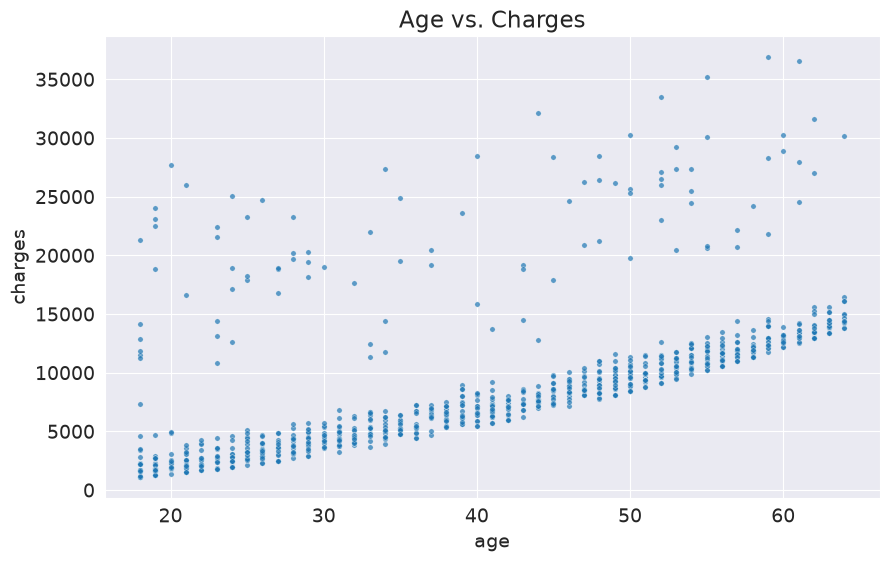

In [11]:
plt.title('Age vs. Charges')
sns.scatterplot(data=non_smoker_df, x='age', y='charges', alpha=0.7, s=15); # 's' = size of points

Apart from a few exceptions, the points seem to form a line. We'll try and "fit" a line using this points, and use the line to predict charges for a given age. A line on the X&Y coordinates has the following formula:

$y = wx + b$

The line is characterized two numbers: $w$ (called "slope") and $b$ (called "intercept"). 

### Model

In the above case, the x axis shows "age" and the y axis shows "charges". Thus, we're assume the following relationship between the two:

$charges = w \times age + b$

We'll try determine $w$ and $b$ for the line that best fits the data. 

* This technique is called _linear regression_, and we call the above equation a _linear regression model_, because it models the relationship between "age" and "charges" as a straight line. 

* The numbers $w$ and $b$ are called the _parameters_ or _weights_ of the model.

* The values in the "age" column of the dataset are called the _inputs_ to the model and the values in the charges column are called "targets". 

Let define a helper function `estimate_charges`, to compute $charges$, given $age$, $w$ and $b$.

In [12]:
def estimate_charges(age, w, b):
    return w * age + b

## The Formula: Why $y = wx + b$?
**This equation is not arbitrary; it is the fundamental mathematical definition of a straight line.**

**In Machine Learning, we adapt the classic geometry form ($y = mx + c$) to ML notation ($y = wx + b$):**

$y$ (Target): The value we want to predict (e.g., charges).  
$x$ (Input/Feature): The known data point (e.g., age).  
$w$ and $b$ (Parameters): The values the algorithm must learn to minimize prediction error.  


*Why use this simple model?*

**Simplicity & Efficiency:** It is the most computationally efficient way to relate two variables and is easy to interpret.  
**Universal Approximation:** Many real-world phenomena (like age vs. medical costs) follow linear patterns or can be approximated by them.  
**Foundation of Deep Learning:** Complex Neural Networks are essentially thousands of these linear equations stacked together with non-linear activation functions.  

The `estimate_charges` function is our very first _model_.

Let's _guess_ the values for $w$ and $b$ and use them to estimate the value for charges.

In [13]:
w = 50 # Weight vs Slope
b = 100 # Bias/Skewness vs Intercept

## The Parameters: Weight ($w$) vs. Bias ($b$)

*When defining these variables in your code, it is crucial to use the correct terminology for the Machine Learning context.*

*While mathematically they are called **slope** and **intercept**, in ML they represent **importance** and **baseline offset**.*


### $w$ = Weight (Slope)

* **Mathematical Name:** Slope ($m$)
* **ML Name:** Weight
* **Physical Meaning:** Represents the **rate of change**. It answers: *"How much does the target increase for every single unit increase in the feature?"*

**In this model:**

If $w = 50$, then for every additional year of age, medical charges increase by **50 units**.

* **High $w$:** The line is steep; age has a strong impact on cost.
* **Low $w$:** The line is flat; age has little impact.

**Why "Weight"?**
It determines how much **weight** or importance the input feature (age) carries in the final prediction.


### $b$ = Bias (Intercept)

* **Mathematical Name:** Y-Intercept ($c$)
* **ML Name:** Bias
* **Physical Meaning:** The value of $y$ when $x = 0$. It is the **baseline prediction** before considering the input feature.

**In this model:**

Represents the estimated cost for a person of **0 years old**. Even a newborn has base costs (administrative fees and basic care risk). This is **$b$**.

**Without $b$:**  
The line would be forced to pass through the origin $(0,0)$, assuming a baby costs **0**, which would cause massive errors.

**Why "Bias"?**  
It allows the model to shift the line up or down to fit the data better, introducing a necessary **bias** or assumption about the base value independent of the input.


In [14]:
ages = non_smoker_df.age 
estimated_charges = estimate_charges(ages, w, b)

We can plot the estimated charges using a line graph.

Text(0, 0.5, 'Estimated Charges')

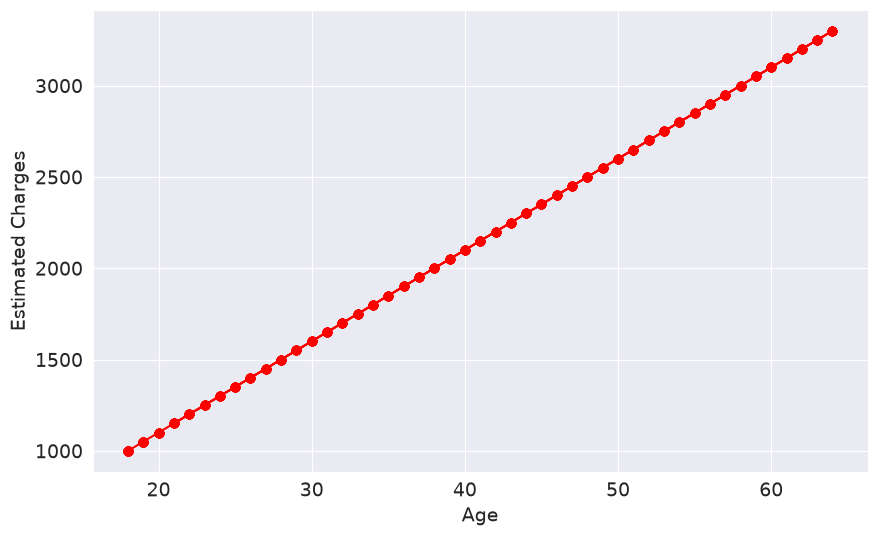

In [15]:
# Visualize predictions: red line ('r'), solid connect ('-'), circle points ('o').
plt.plot(ages, estimated_charges, 'r-o');
plt.xlabel('Age')
plt.ylabel('Estimated Charges')

As expected, the points lie on a straight line. 

We can overlay this line on the actual data, so see how well our _model_ fits the _data_.

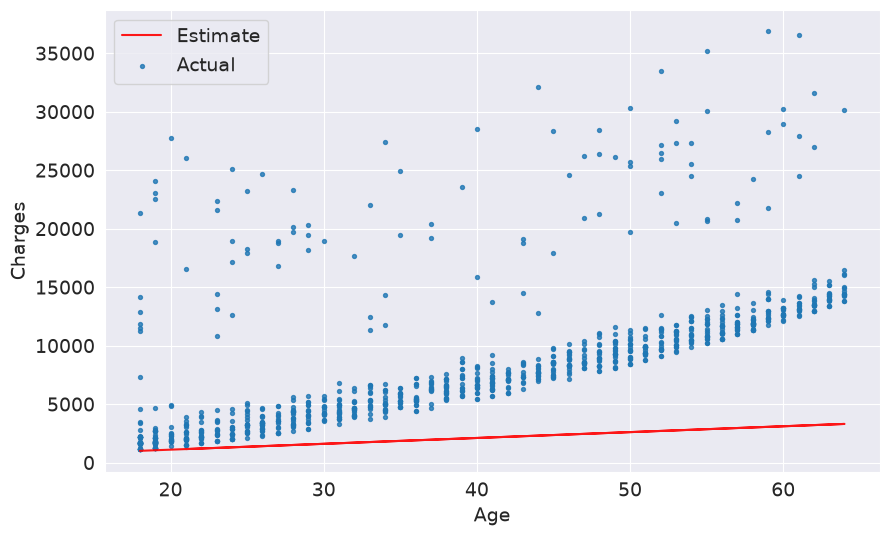

In [16]:
target = non_smoker_df.charges

plt.plot(ages, estimated_charges, 'r', alpha=0.9);
plt.scatter(ages, target, s=8, alpha=0.8);
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend(['Estimate', 'Actual']);

Clearly, the our estimates are quite poor and the line does not "fit" the data. However, we can try different values of $w$ and $b$ to move the line around. Let's define a helper function `try_parameters` which takes `w` and `b` as inputs and creates the above plot.

In [17]:
def try_parameters(w, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges
    
    estimated_charges = estimate_charges(ages, w, b)
    
    plt.plot(ages, estimated_charges, 'r', alpha=0.9); # 'r' = red
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual']);

## Visualizing the Fit

When you manually adjust the parameters in `try_parameters(w, b)`:

* Changing **$w$** rotates the line (making it steeper or flatter).
* Changing **$b$** moves the line vertically (up or down).

The goal of the Linear Regression algorithm (using `.fit()` or Gradient Descent later) is to automatically find the values of **$w$** and **$b$** that minimize the distance between the **red line** (predictions) and the **blue dots** (actual data).


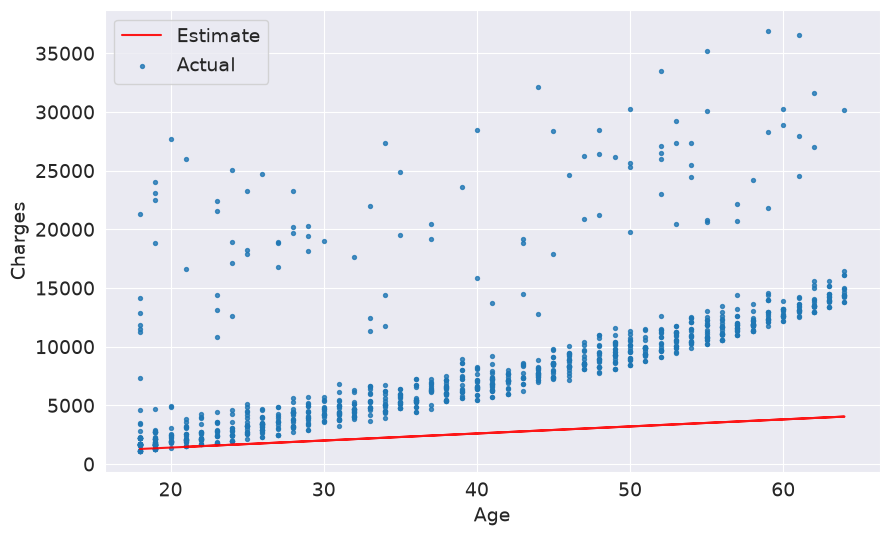

In [18]:
try_parameters(60, 200)

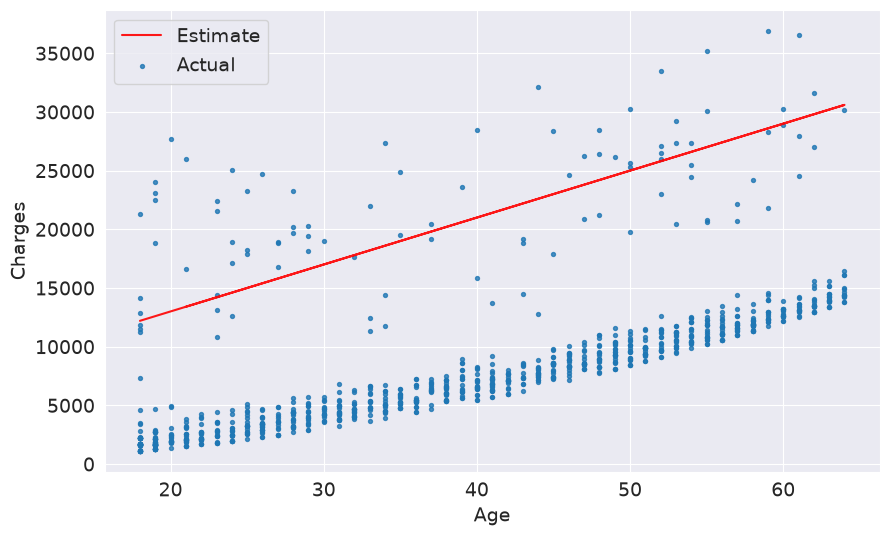

In [19]:
try_parameters(400, 5000)

> **EXERCISE**: Try various values of $w$ and $b$ to find a line that best fits the data. What is the effect of changing the value of $w$? What is the effect of changing $b$?

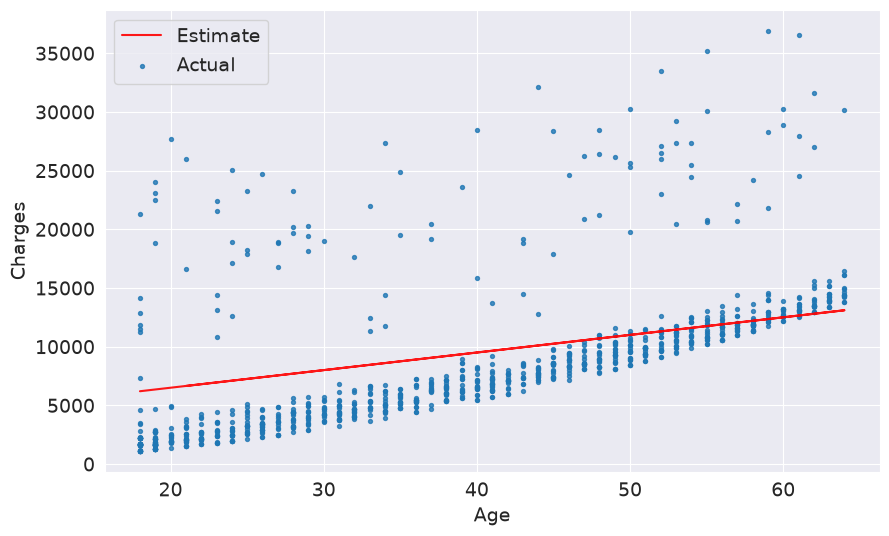

In [20]:
try_parameters(150, 3500)

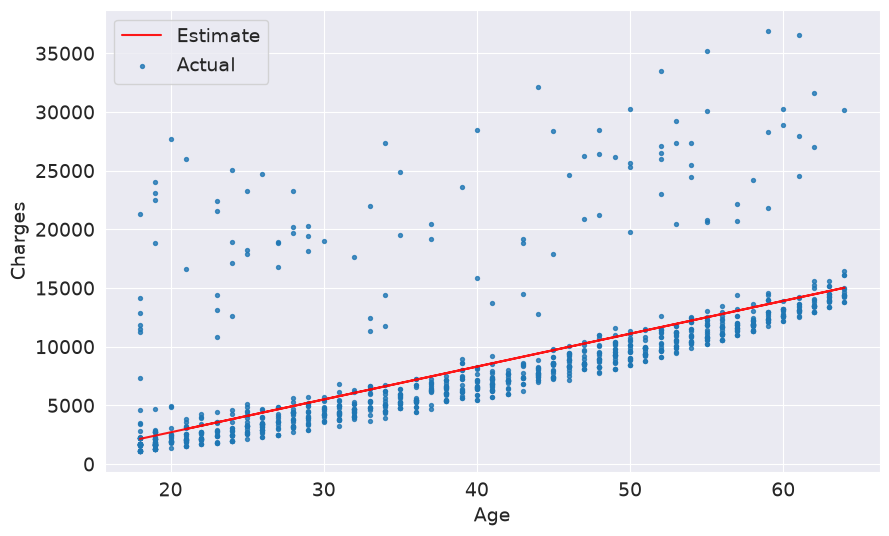

In [21]:
try_parameters(280, -2900)

As we change the values, of $w$ and $b$ manually, trying to move the line visually closer to the points, we are _learning_ the approximate relationship between "age" and "charges". 

Wouldn't it be nice if a computer could try several different values of `w` and `b` and _learn_ the relationship between "age" and "charges"? To do this, we need to solve a couple of problems:

1. We need a way to measure numerically how well the line fits the points.

2. Once the "measure of fit" has been computed, we need a way to modify `w` and `b` to improve the the fit.

If we can solve the above problems, it should be possible for a computer to determine `w` and `b` for the best fit line, starting from a random guess.

### Loss/Cost Function

We can compare our model's predictions with the actual targets using the following method:

* Calculate the difference between the targets and predictions (the differenced is called the "residual")
* Square all elements of the difference matrix to remove negative values.
* Calculate the average of the elements in the resulting matrix.
* Take the square root of the result

The result is a single number, known as the **root mean squared error** (RMSE). The above description can be stated mathematically as follows: 

<img src="https://i.imgur.com/WCanPkA.png" width="360">

Geometrically, the residuals can be visualized as follows:

<img src="https://i.imgur.com/ll3NL80.png" width="420">

Let's define a function to compute the RMSE.

In [22]:
import numpy as np

In [23]:
def rmse(targets, predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))

Let's compute the RMSE for our model with a sample set of weights

In [24]:
w = 50
b = 100

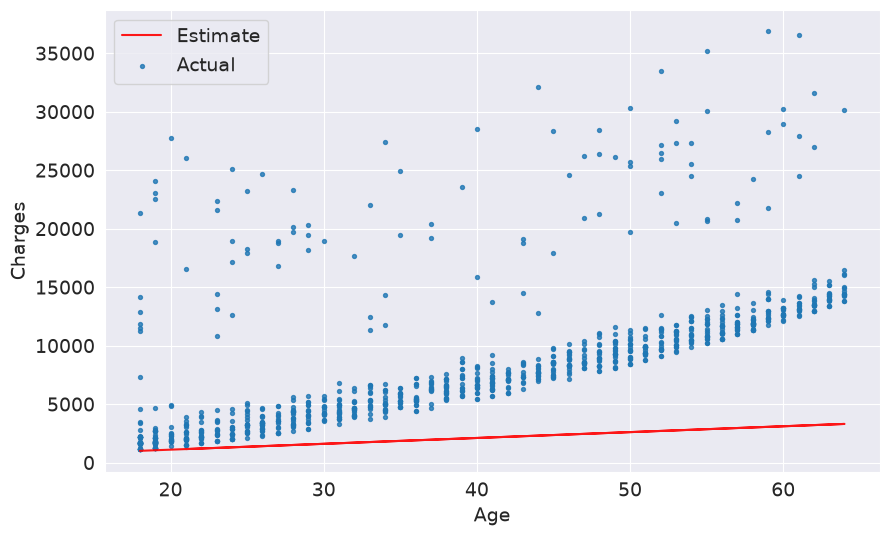

In [25]:
try_parameters(w, b)

In [26]:
targets = non_smoker_df['charges']
predicted = estimate_charges(non_smoker_df.age, w, b)

In [27]:
rmse(targets, predicted)

np.float64(8461.949562575493)

Here's how we can interpret the above number: *On average, each element in the prediction differs from the actual target by \\$8461*. 

The result is called the *loss* because it indicates how bad the model is at predicting the target variables. It represents information loss in the model: the lower the loss, the better the model.

Let's modify the `try_parameters` functions to also display the loss.

In [28]:
def try_parameters(w, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges
    predictions = estimate_charges(ages, w, b)

    plt.plot(ages, predictions, 'r', alpha=0.9)
    plt.scatter(ages, target, s=8, alpha=0.8)
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Prediction', 'Actual']);

    loss = rmse(target, predictions)
    print("RMSE Loss: ", loss)

RMSE Loss:  8461.949562575493


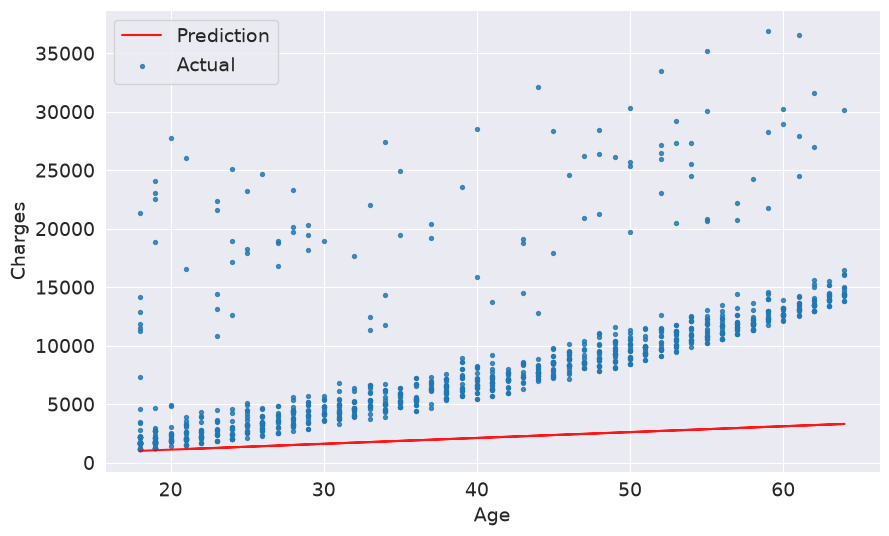

In [29]:
try_parameters(50, 100)

> **EXERCISE**: Try different values of $w$ and $b$ to minimize the RMSE loss. What's the lowest value of loss you are able to achieve? Can you come with a general strategy for finding better values of $w$ and $b$ by trial and error?

RMSE Loss:  4676.007165884022


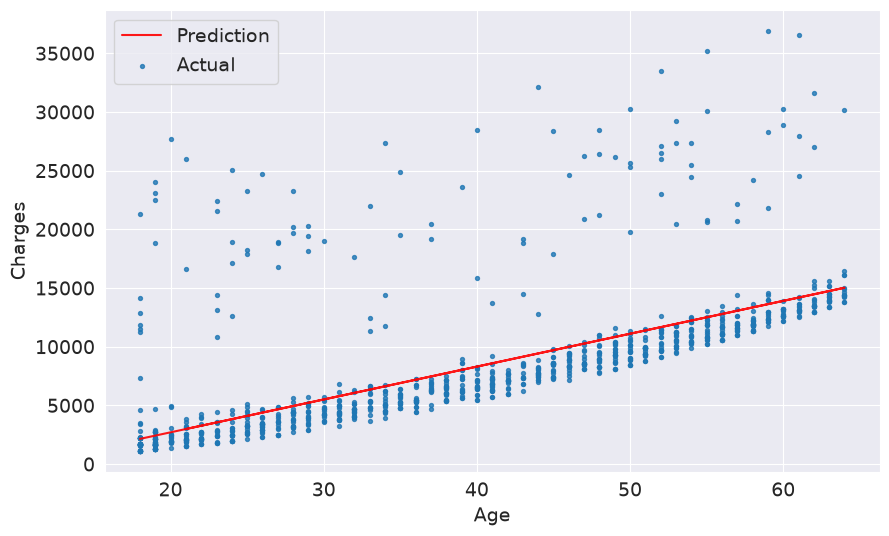

In [30]:
try_parameters(280, -2900)

RMSE Loss:  4668.390759792892


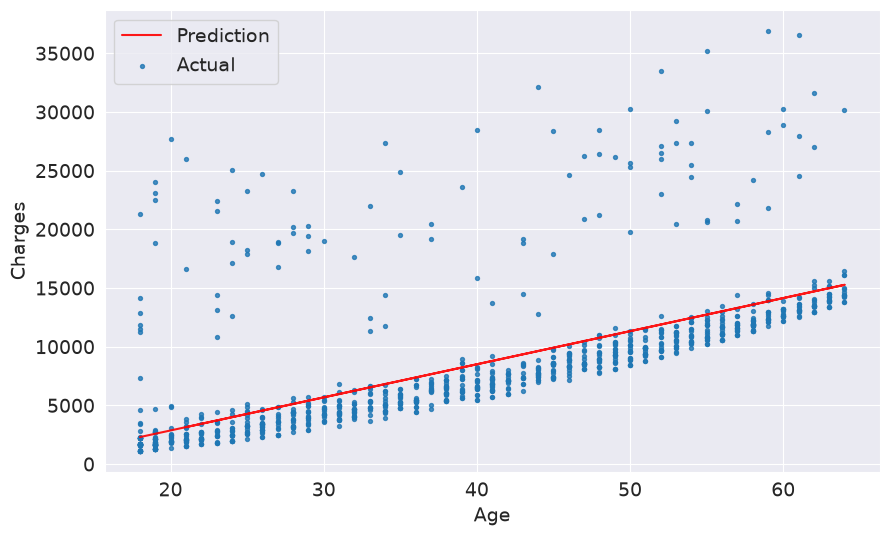

In [31]:
try_parameters(282, -2781)

### Optimizer

Next, we need a strategy to modify weights `w` and `b` to reduce the loss and improve the "fit" of the line to the data.

* Ordinary Least Squares: https://www.youtube.com/watch?v=szXbuO3bVRk (better for smaller datasets)
* Stochastic gradient descent: https://www.youtube.com/watch?v=sDv4f4s2SB8 (better for larger datasets)

Both of these have the same objective: to minimize the loss, however, while ordinary least squares directly computes the best values for `w` and `b` using matrix operations, while gradient descent uses a iterative approach, starting with a random values of `w` and `b` and slowly improving them using derivatives. 

Here's a visualization of how gradient descent works:

![](https://miro.medium.com/max/1728/1*NO-YvpHHadk5lLxtg4Gfrw.gif)

Doesn't it look similar to our own strategy of gradually moving the line closer to the points?


## 🧠 Deep Dive: The Optimizer

The **Optimizer** is the engine behind Machine Learning. Its sole purpose is to find the best values for the model parameters (**weights $w$** and **bias $b$**) to minimize the error between predictions and actual data.

Think of the **Loss Function** as a mountain landscape. The optimizer's job is to find the lowest point in the valley (minimum error).

### 🔑 Key Terminology

*   **Gradient / Slope**: The **gradient** is essentially the **slope** of the loss function at a specific point.  It indicates the direction and steepness of the increase in error.
    *   *Intuition*: If you are on a hill, the gradient points "up." To minimize error, we move in the *opposite* direction (downhill).
*   **Loss Function**: A formula (like Mean Squared Error) calculating "how wrong" the model is. 
*   **Learning Rate**: The **size of the steps** the optimizer takes.
    *   *Too small*: Slow convergence.
    *   *Too large*: May overshoot the minimum.
*   **Convergence**: When the optimizer finds the minimum and the loss stops decreasing. 

### ⚔️ The Two Main Strategies (Both are Linear Regression!)

It is crucial to understand: **Both methods produce the exact same type of model** (a Linear Regression line $y = wx + b$).  The only difference is the **mathematical strategy** used to find the line. 

#### 1. Ordinary Least Squares (OLS)
*   **Class**: `LinearRegression`
*   **Approach**: Analytical (Direct Formula). Uses matrix operations to calculate the **exact** solution in one step. 
*   **Best For**: **Small to Medium Datasets (< 100,000 rows)**. 
*   **Pros**: Fast, exact, no hyperparameters to tune. 
*   **Cons**: Computationally expensive ($O(n^3)$) for massive data; cannot fit data that doesn't fit in RAM. 

#### 2. Stochastic Gradient Descent (SGD)
*   **Class**: `SGDRegressor`
*   **Approach**: Iterative. Starts with random values and gradually improves them by following the gradient. 
*   **Best For**: **Large Datasets (> 100,000 rows)** or data that doesn't fit in memory. 
*   **Pros**: Scales efficiently; can learn from data streams. 
*   **Cons**: Requires **Feature Scaling** (critical!); needs tuning of *Learning Rate* and *Iterations*; gives an approximate solution. 

### 📏 When to use which? (Rule of Thumb)

| Dataset Size | Recommended Model | Why? |
| :--- | :--- | :--- |
| **Small / Medium**<br>*(< 100k rows)* | `LinearRegression` (OLS) | It provides the **exact** mathematical solution instantly.  No need to tune parameters. |
| **Large**<br>*(100k – 1M+ rows)* | `SGDRegressor` | OLS becomes too slow.  SGD approximates the solution much faster. |
| **Massive / Out-of-Core**<br>*(Doesn't fit in RAM)* | `SGDRegressor` | **Only** SGD can handle this by processing data in small batches.  |

> **💡 Important Note on Scaling**: `SGDRegressor` is highly sensitive to feature scales. You **must** scale your data (e.g., using `StandardScaler`) before using it, or it may fail to converge.  `LinearRegression` does not require scaling.

### 💻 Why don't we implement this from scratch?
Libraries like **Scikit-Learn** handle the complex math for you:
1.  **Optimization**: Highly optimized C++ backends.
2.  **Stability**: Handles edge cases (like singular matrices) automatically.
3.  **Abstraction**: Allows you to focus on data quality and evaluation rather than calculus. 

When you call `model.fit()`:
*   `LinearRegression` uses **OLS** (via SVD decomposition). 
*   `SGDRegressor` uses **Stochastic Gradient Descent**.   

In [32]:
import numpy as np
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# 1. Generate a "Medium" dataset (50,000 rows) to show both work well
X, y = make_regression(n_samples=50000, n_features=1, noise=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

# --- OPTION A: LinearRegression (OLS) ---
# ✅ No scaling needed for OLS
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)
pred_ols = ols_model.predict(X_test)
mse_ols = mean_squared_error(y_test, pred_ols)

# --- OPTION B: SGDRegressor (Gradient Descent) ---
# ⚠️ CRITICAL: Must scale data for Gradient Descent to work properly!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# We set max_iter high enough to ensure convergence
sgd_model = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
sgd_model.fit(X_train_scaled, y_train)
pred_sgd = sgd_model.predict(X_test_scaled)
mse_sgd = mean_squared_error(y_test, pred_sgd)

# --- Results Comparison ---
print(f"{'Model':<25} | {'MSE (Error)':<15} | {'R² Score':<10}")
print("-" * 55)
print(f"{'LinearRegression (OLS)':<25} | {mse_ols:<15.4f} | {ols_model.score(X_test, y_test):.4f}")
print(f"{'SGDRegressor (Scaled)':<25} | {mse_sgd:<15.4f} | {sgd_model.score(X_test_scaled, y_test):.4f}") 

print("\n✅ Conclusion: Both models achieve nearly identical performance.")
print("   They are both Linear Regression, just using different optimizers!")   

Model                     | MSE (Error)     | R² Score  
-------------------------------------------------------
LinearRegression (OLS)    | 102.0510        | 0.0016
SGDRegressor (Scaled)     | 102.1041        | 0.0011

✅ Conclusion: Both models achieve nearly identical performance.
   They are both Linear Regression, just using different optimizers!


### Linear Regression using Scikit-learn

In practice, you'll never need to implement either of the above methods yourself. You can use a library like `scikit-learn` to do this for you. 

Let's use the `LinearRegression` class from `scikit-learn` to find the best fit line for "age" vs. "charges" using the ordinary least squares optimization technique.

In [33]:
from sklearn.linear_model import LinearRegression

First, we create a new model object.

In [34]:
model = LinearRegression()

Next, we can use the `fit` method of the model to find the best fit line for the inputs and targets.

In [35]:
help(model.fit)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.
    
    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.
    
    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.
    
    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.
    
        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.
    
    Returns
    -------
    self : object
        Fitted Estimator.



Not that the input `X` must be a 2-d array, so we'll need to pass a dataframe, instead of a single column.

In [36]:
inputs = non_smoker_df[['age']]
targets = non_smoker_df.charges
print('inputs.shape :', inputs.shape)
print('targets.shape :', targets.shape)

inputs.shape : (1064, 1)
targets.shape : (1064,)


Let's fit the model to the data.

In [ ]:
# here we telling to sklearn: these are some inputs, and here are the targets for those inputs
# these are some ages and these are teh charges for these ages
# can u plis firs guess some randome w and b and compare the predictions with the targets, see how
# bad the predictions are and then use a gradient descent algorthm or use some other optimization strategy
# to impotve the values of w and b and keep improving until you cant improve anymore, and then give me the final result
model.fit(inputs, targets)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[267.25]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['age']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2091
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


We can now make predictions using the model. Let's try predicting the charges for the ages 23, 37 and 61

In [38]:
model.predict(np.array([[23],
                        [37],
                        [61]]))

/home/pulpo/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 4055.30443855,  7796.78921819, 14210.76312614])

Do these values seem reasonable? Compare them with the scatter plot above.

Let compute the predictions for the entire set of inputs

In [39]:
predictions = model.predict(inputs)

In [40]:
predictions

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289], shape=(1064,))

Let's compute the RMSE loss to evaluate the model.

In [43]:
rmse(targets, predictions)

np.float64(4662.505766636395)

Seems like our prediction is off by $4000 on average, which is not too bad considering the fact that there are several outliers.

The parameters of the model are stored in the `coef_` and `intercept_` properties.

In [44]:
# w
model.coef_

array([267.24891283])

In [45]:
# b
model.intercept_

np.float64(-2091.4205565650864)

Are these parameters close to your best guesses?

Let's visualize the line created by the above parameters.

RMSE Loss:  4662.505766636395


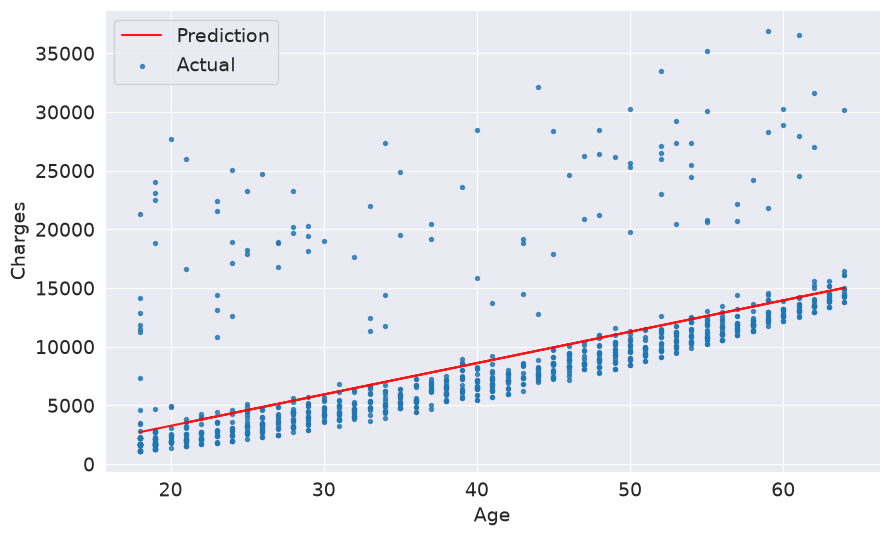

In [46]:
try_parameters(model.coef_, model.intercept_)

Indeed the line is quite close to the points. It is slightly above the cluster of points, because it's also trying to account for the outliers. 

> **EXERCISE**: Use the [`SGDRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html) class from `scikit-learn` to train a model using the stochastic gradient descent technique. Make predictions and compute the loss. Do you see any difference in the result?